In [1]:
import sys
!{sys.executable} -m pip install scikit-learn lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [2]:
####TAXI
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pyarrow fastparquet

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
!{sys.executable} -m pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import sys
# Aggiorna pandas e pyarrow insieme per garantire la compatibilità
!{sys.executable} -m pip install --upgrade pandas pyarrow

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import pandas as pd
import glob
import gc

# 1. Definisci ESATTAMENTE le colonne che ti servono
# (Controlla i nomi esatti nel dataset, ad esempio:)
colonne_utili = [
    'pickup_datetime',
    'request_datetime',
    'PULocationID'
    ]

# 2. Usa glob per prendere tutti i file senza scriverli uno a uno
path = "/Users/robmormandi/Downloads/fhvhv_tripdata_2025-*.parquet"
files = glob.glob(path)

df_list = []

for f in files:
    print(f"Caricamento ottimizzato di: {f}")
    # Leggiamo SOLO le colonne utili
    temp_df = pd.read_parquet(f, columns=colonne_utili)
    
    # OPZIONALE: Converti i tipi di dati per risparmiare ulteriore RAM
    # Esempio: i LocationID sono spesso int64, ma basta un int32
    # temp_df['PULocationID'] = temp_df['PULocationID'].astype('int32')
    
    df_list.append(temp_df)

# 3. Concatena tutto
print("Concatenazione in corso...")
dftot = pd.concat(df_list, ignore_index=True)

# 4. Pulizia finale della memoria temporanea
del df_list
gc.collect()

print("Fatto! Memoria utilizzata dal DataFrame:", dftot.memory_usage(deep=True).sum() / 1e9, "GB")

Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-04.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-05.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-07.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-06.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-03.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-02.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-12.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-10.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-09.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-08.parquet
Caricamento ottimizzato di: /Users/robmormandi/Downloads/fhvhv_tripdata_2025-01.parquet
Caricamento ottimizzato di: /Use

In [ ]:
import pandas as pd

# ── 1. Calcola il waiting time in minuti ────────────────────────────────────
dftot['waiting_time'] = (dftot['pickup_datetime'] - dftot['request_datetime']).dt.total_seconds() / 60

# ── 2. Rimuovi valori assurdi ────────────────────────────────────────────────
dftot = dftot[dftot['waiting_time'] >= 0]
dftot = dftot[dftot['waiting_time'] <= 120]

# ── 3. Time bucket e info temporali ─────────────────────────────────────────
dftot['time_bucket'] = dftot['request_datetime'].dt.floor('15min')
dftot['year']        = dftot['request_datetime'].dt.year
dftot['month']       = dftot['request_datetime'].dt.month
dftot['day_of_week'] = dftot['request_datetime'].dt.dayofweek
dftot['day_name']    = dftot['request_datetime'].dt.day_name()

# ── 4. Raggruppa ─────────────────────────────────────────────────────────────
grouped = (
    dftot.groupby(['time_bucket', 'PULocationID', 'year', 'month', 'day_of_week', 'day_name'])
    .agg(
        avg_waiting_time=('waiting_time', 'mean'),
        num_rides=('waiting_time', 'count'),
    )
    .reset_index()
    .sort_values(['PULocationID', 'time_bucket'])
    .reset_index(drop=True)
)

# ── 5. Festivi federali USA 2025 ─────────────────────────────────────────────
holidays_2025 = pd.to_datetime([
    '2025-01-01',  # New Year's Day
    '2025-01-20',  # Martin Luther King Jr. Day
    '2025-02-17',  # Presidents' Day
    '2025-05-26',  # Memorial Day
    '2025-06-19',  # Juneteenth
    '2025-07-04',  # Independence Day
    '2025-09-01',  # Labor Day
    '2025-10-13',  # Columbus Day
    '2025-11-11',  # Veterans Day
    '2025-11-27',  # Thanksgiving
    '2025-12-25',  # Christmas
])

# ── 6. Colonne festivi ───────────────────────────────────────────────────────
date_col = grouped['time_bucket'].dt.normalize()

grouped['is_holiday'] = date_col.isin(holidays_2025).astype(int)
grouped['is_sunday']  = (grouped['day_of_week'] == 6).astype(int)
grouped['is_festivo'] = ((grouped['is_holiday'] == 1) | (grouped['is_sunday'] == 1)).astype(int)

# ── 7. Verifica ──────────────────────────────────────────────────────────────
print(grouped[['time_bucket', 'day_name', 'is_holiday', 'is_sunday', 'is_festivo']]
      .drop_duplicates('time_bucket')
      .sort_values('time_bucket')
      .head(30))

hrouped.head()


                time_bucket   day_name  is_holiday  is_sunday  is_festivo
5043123 2024-12-31 22:30:00    Tuesday           0          0           0
1422169 2024-12-31 23:00:00    Tuesday           0          0           0
4057642 2024-12-31 23:15:00    Tuesday           0          0           0
1422170 2024-12-31 23:30:00    Tuesday           0          0           0
35429   2024-12-31 23:45:00    Tuesday           0          0           0
655     2025-01-01 00:00:00  Wednesday           1          0           1
656     2025-01-01 00:15:00  Wednesday           1          0           1
657     2025-01-01 00:30:00  Wednesday           1          0           1
658     2025-01-01 00:45:00  Wednesday           1          0           1
659     2025-01-01 01:00:00  Wednesday           1          0           1
660     2025-01-01 01:15:00  Wednesday           1          0           1
661     2025-01-01 01:30:00  Wednesday           1          0           1
662     2025-01-01 01:45:00  Wednesday

In [15]:
grouped.head()
grouped.describe()

,time_bucket,PULocationID,year,month,day_of_week,avg_waiting_time,num_rides,is_holiday,is_sunday,is_festivo
count,8499310,8.499310e+06,8.499310e+06,8.499310e+06,8.499310e+06,8.499310e+06,8.499310e+06,8.499310e+06,8.499310e+06,8.499310e+06
mean,2025-07-02 17:19:28.471464,1.348634e+02,2.025000e+03,6.533492e+00,3.009554e+00,4.971112e+00,2.833151e+01,3.015186e-02,1.434306e-01,1.735824e-01
min,2024-12-31 22:30:00,1.000000e+00,2.024000e+03,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2025-04-02 18:00:00,6.900000e+01,2.025000e+03,4.000000e+00,1.000000e+00,3.819298e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2025-07-02 19:45:00,1.370000e+02,2.025000e+03,7.000000e+00,3.000000e+00,4.550000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
75%,2025-10-01 18:45:00,2.010000e+02,2.025000e+03,1.000000e+01,5.000000e+00,5.624275e+00,3.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00
max,2025-12-31 23:45:00,2.650000e+02,2.025000e+03,1.200000e+01,6.000000e+00,1.189833e+02,8.300000e+02,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,7.564762e+01,5.213247e-03,3.443983e+00,1.998738e+00,1.878735e+00,2.978313e+01,1.710051e-01,3.505114e-01,3.787500e-01


In [7]:
grouped.to_parquet("/Users/robmormandi/Desktop/grouped_15min_zones.parquet", index=False)

/var/folders/zj/8xrdskzj2r992rf08_jpvyf80000gn/T/ipykernel_8871/2238146619.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['PULocationID'] = X['PULocationID'].astype('category')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032561 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 6799448, number of used features: 9
[LightGBM] [Info] Start training from score 4.971029
Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 2.30696
[200]	valid_0's l2: 2.2085
[300]	valid_0's l2: 2.16444
[400]	valid_0's l2: 2.14973
[500]	valid_0's l2: 2.13908
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[600]	valid_0's l2: 2.13178
[700]	valid_0's l2: 2.12586
[800]	valid_0's l2: 2.12064
[900]	valid_0's l2: 2.11608
[1000]	valid_0's l2: 2.11224
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 2.11224

MAE  : 0.91 minuti
RMSE : 1.45 minuti
R²   : 0.3988

Accuracy: 0.5877
              precision    rec

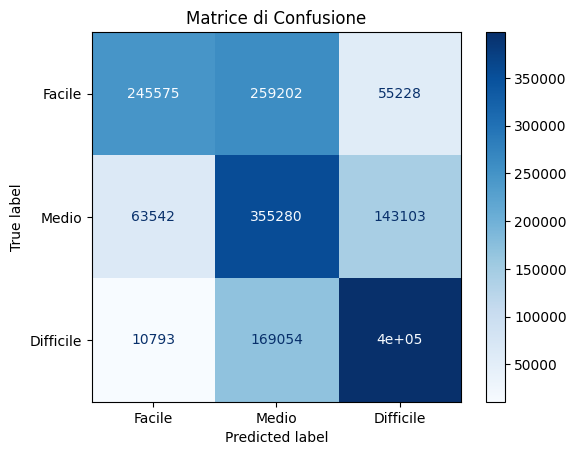

In [16]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import joblib



# ── 2. Feature engineering ───────────────────────────────────────────────────
grouped['hour']   = grouped['time_bucket'].dt.hour
grouped['minute'] = grouped['time_bucket'].dt.minute

grouped['hour_sin']   = np.sin(2 * np.pi * grouped['hour'] / 24)
grouped['hour_cos']   = np.cos(2 * np.pi * grouped['hour'] / 24)
grouped['dow_sin']    = np.sin(2 * np.pi * grouped['day_of_week'] / 7)
grouped['dow_cos']    = np.cos(2 * np.pi * grouped['day_of_week'] / 7)
grouped['minute_sin'] = np.sin(2 * np.pi * grouped['minute'] / 60)
grouped['minute_cos'] = np.cos(2 * np.pi * grouped['minute'] / 60)

TARGET = 'avg_waiting_time'
grouped = grouped.dropna(subset=[TARGET])

# ── 3. Features ──────────────────────────────────────────────────────────────
FEATURES = [
    'PULocationID',      # LightGBM la gestisce come categorica nativamente
    'hour_sin', 'hour_cos',
    'minute_sin', 'minute_cos',
    'dow_sin', 'dow_cos',
    'month',
    'is_festivo'
]

X = grouped[FEATURES]
y = grouped[TARGET]

# Dichiara PULocationID come categorica
X['PULocationID'] = X['PULocationID'].astype('category')

# ── 4. Split ─────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 5. Modello ───────────────────────────────────────────────────────────────
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[
        lgb.early_stopping(50),      # stop se non migliora per 50 round
        lgb.log_evaluation(100)      # stampa ogni 100 round
    ]
)

# ── 6. Valutazione regressione ───────────────────────────────────────────────
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\nMAE  : {mae:.2f} minuti")
print(f"RMSE : {rmse:.2f} minuti")
print(f"R²   : {r2:.4f}")

# ── 7. Soglie e metriche classificazione ─────────────────────────────────────
p33 = np.percentile(y, 33)
p66 = np.percentile(y, 66)

def to_class(values):
    return pd.cut(pd.Series(values).reset_index(drop=True),
                  bins=[-np.inf, p33, p66, np.inf],
                  labels=['Facile', 'Medio', 'Difficile'])

y_test_class = to_class(y_test.values)
y_pred_class = to_class(y_pred)

print(f"\nAccuracy: {accuracy_score(y_test_class, y_pred_class):.4f}")
print(classification_report(y_test_class, y_pred_class))

disp = ConfusionMatrixDisplay(
    confusion_matrix(y_test_class, y_pred_class, labels=['Facile','Medio','Difficile']),
    display_labels=['Facile','Medio','Difficile']
)
disp.plot(cmap='Blues')
plt.title("Matrice di Confusione")
plt.show()



In [ ]:
# ── 8. Salva ─────────────────────────────────────────────────────────────────
joblib.dump(model, "/Users/robmormandi/Desktop/waiting_time_lgbm.pkl")
joblib.dump({'p33': p33, 'p66': p66}, "/Users/robmormandi/Desktop/thresholds.pkl")


#######il modello è qui

# ── 9. Funzione predizione ────────────────────────────────────────────────────
def predict_waiting(location_id, datetime_input):
    dt = pd.to_datetime(datetime_input).floor('15min')
    
    # Calcola is_festivo
    holidays_2025 = pd.to_datetime([
        '2025-01-01','2025-01-20','2025-02-17','2025-05-26',
        '2025-06-19','2025-07-04','2025-09-01','2025-10-13',
        '2025-11-11','2025-11-27','2025-12-25'
    ])
    is_festivo = int(dt.date() in holidays_2025 or dt.dayofweek == 6)

    features = pd.DataFrame([{
        'PULocationID': pd.Categorical([location_id], categories=X['PULocationID'].cat.categories)[0],
        'hour_sin':     np.sin(2 * np.pi * dt.hour / 24),
        'hour_cos':     np.cos(2 * np.pi * dt.hour / 24),
        'minute_sin':   np.sin(2 * np.pi * dt.minute / 60),
        'minute_cos':   np.cos(2 * np.pi * dt.minute / 60),
        'dow_sin':      np.sin(2 * np.pi * dt.dayofweek / 7),
        'dow_cos':      np.cos(2 * np.pi * dt.dayofweek / 7),
        'month':        dt.month,
        'is_festivo':   is_festivo
    }])
    features['PULocationID'] = features['PULocationID'].astype('category')

    wt = model.predict(features)[0]
    label = "🟢 Facile" if wt < p33 else "🟡 Medio" if wt < p66 else "🔴 Difficile"

    print(f"\nZona: {location_id} | {dt.strftime('%A %d/%m %H:%M')}")
    print(f"Waiting time stimato : {wt:.1f} minuti")
    print(f"Disponibilità taxi   : {label}")
    return wt, label

# ── Esempio ───────────────────────────────────────────────────────────────────
predict_waiting(location_id=161, datetime_input='2025-01-15 08:30')


Zona: 161 | Wednesday 15/01 08:30
Waiting time stimato : 3.2 minuti
Disponibilità taxi   : 🟢 Facile


(np.float64(3.2133421190502967), '🟢 Facile')